1. Daily Returns
2. CAGR
3. Sharpe Ratio
4. Sortino Ratio
5. Alpha & Beta
6. Maximum Drawdown
7. Fund Scorecard
8. Benchmark Comparison

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [2]:
funds = pd.read_csv(
    "data/processed/01_fund_master.csv"
    
)

nav = pd.read_csv(
    "data/processed/02_nav_history.csv"
)

In [3]:
print(funds.shape)
print(nav.shape)

nav.head()

(40, 15)
(64320, 5)


,amfi_code,date,date_key,nav,is_forward_filled
0,100016,2022-01-03,20220103,520.4608,False
1,100016,2022-01-04,20220104,515.0971,False
2,100016,2022-01-05,20220105,521.7239,False
3,100016,2022-01-06,20220106,515.7880,False
4,100016,2022-01-07,20220107,515.1639,False


In [4]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

In [5]:
nav_df = nav.merge(
    funds[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [6]:
print(nav_df.shape)

nav_df.head()

(64320, 8)


,amfi_code,date,date_key,nav,is_forward_filled,scheme_name,fund_house,category
0,100016,2022-01-03,20220103,520.4608,False,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
1,100016,2022-01-04,20220104,515.0971,False,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
2,100016,2022-01-05,20220105,521.7239,False,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
3,100016,2022-01-06,20220106,515.7880,False,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
4,100016,2022-01-07,20220107,515.1639,False,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity


In [7]:
nav_pivot = nav_df.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

In [8]:
print(nav_pivot.shape)

nav_pivot.head()

(1608, 40)


scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Pru Liquid Fund - Regular - Growth,ICICI Pru Midcap Fund - Regular - Growth,ICICI Pru Value Discovery Fund - Regular - Growth,Kotak Bluechip Fund - Regular - Growth,Kotak Emerging Equity Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,Kotak Liquid Fund - Regular - Growth,Mirae Asset Emerging Bluechip Fund - Regular - Growth,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset Tax Saver Fund - Regular - Growth,Nippon India ETF Nifty 50 BeES,Nippon India Gilt Securities Fund - Regular - Growth,Nippon India Large Cap Fund - Direct - Growth,Nippon India Large Cap Fund - Regular - Growth,Nippon India Small Cap Fund - Regular - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-03,305.0996,310.7415,38.5736,41.8140,38.7466,68.3023,52.5238,78.4622,81.6814,348.7159,117.5969,107.3758,26.3169,560.1443,520.4608,60.1474,55.3983,285.7447,135.8720,202.0453,275.8370,62.1265,49.9131,3180.6318,84.0757,70.2514,28.8620,170.3428,30.1152,47.1836,42.8339,69.1076,58.4174,54.3856,42.1391,96.4565,89.8738,191.0721,119.2905,89.8728
2022-01-04,305.4514,310.6977,38.1545,41.8062,38.4924,68.0566,53.5090,78.5000,80.8239,345.7198,117.0077,105.9447,26.2234,560.7052,515.0971,59.4577,55.6327,285.8820,133.1682,202.1501,276.8163,63.2031,50.8195,3181.4042,85.4096,71.6085,29.1038,168.6874,30.2094,46.4910,42.8033,68.8538,57.3480,54.3474,42.2508,94.6512,88.5495,189.0737,120.6402,90.8724
2022-01-05,306.6324,310.8165,38.1775,41.6865,38.2033,69.1860,54.5737,79.1806,80.6143,343.4795,116.4011,105.4800,26.2221,563.0884,521.7239,60.2855,55.9527,286.0699,137.2101,203.6057,276.3892,64.1764,50.1942,3182.8754,84.7554,71.3264,29.5489,166.3925,30.2116,45.9945,43.0564,69.0511,57.0552,54.6869,42.4374,94.5436,88.0925,188.0701,121.4580,90.1565
2022-01-06,305.9800,310.7719,37.0665,41.2775,38.5825,69.1690,54.5502,78.0831,79.9386,342.1680,116.0861,104.9350,26.1728,561.0675,515.7880,60.5202,56.6067,286.1089,136.5355,202.2714,278.9247,64.4521,50.6213,3184.9450,84.3563,72.1746,29.5744,167.0030,30.2180,46.0047,43.2088,68.4476,56.4224,55.4550,42.5901,93.7944,88.5175,190.4545,125.2386,91.5338
2022-01-07,304.0480,310.8388,37.9845,41.6166,38.9425,67.8877,56.3221,78.4202,80.8723,340.7757,114.6164,104.3318,26.2261,559.5420,515.1639,60.6373,57.5741,286.2836,137.8537,203.3482,281.1488,64.2674,49.9391,3185.5042,84.9469,72.2118,29.6091,167.4910,30.2240,46.3033,42.9585,67.0371,57.2750,55.3692,42.4851,89.6438,91.4235,187.3124,124.1321,90.6762


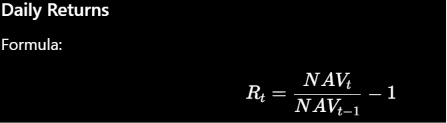

In [9]:
returns = nav_pivot.pct_change()

returns = returns.dropna()

In [10]:
returns.describe().T[
    [
        "mean",
        "std",
        "min",
        "max"
    ]
]

,mean,std,min,max
scheme_name,,,,
ABSL Frontline Equity Fund - Regular - Growth,0.0006,0.0078,-0.0381,0.0340
ABSL Liquid Fund - Regular - Growth,0.0002,0.0003,-0.0008,0.0012
ABSL Small Cap Fund - Regular - Growth,0.0003,0.0137,-0.0518,0.0549
Axis Bluechip Fund - Direct - Growth,0.0002,0.0074,-0.0295,0.0306
Axis Bluechip Fund - Regular - Growth,0.0002,0.0074,-0.0234,0.0336
Axis Midcap Fund - Regular - Growth,0.0007,0.0103,-0.0408,0.0416
Axis Small Cap Fund - Regular - Growth,0.0001,0.0134,-0.0484,0.0431
DSP Midcap Fund - Regular - Growth,0.0008,0.0095,-0.0301,0.0420
DSP Small Cap Fund - Regular - Growth,0.0009,0.0132,-0.0489,0.0485


### Daily Return Validation

Daily returns were computed using percentage NAV changes.

The return distributions appear centered near zero with reasonable volatility ranges and no abnormal spikes, indicating data quality suitable for performance analytics.

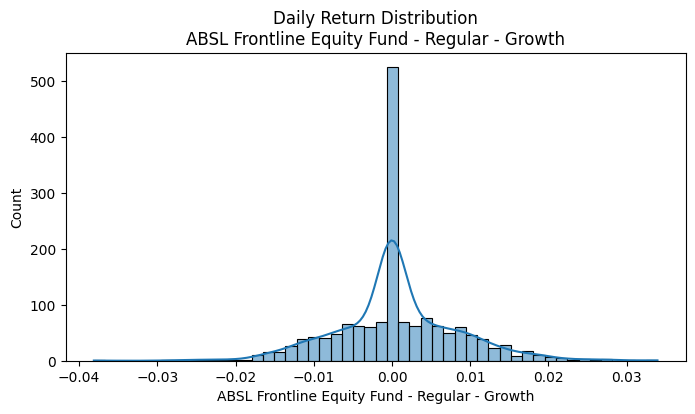

In [12]:
sample_fund = returns.columns[0]

plt.figure(figsize=(8,4))

sns.histplot(
    returns[sample_fund],
    bins=50,
    kde=True
)

plt.title(
    f"Daily Return Distribution\n{sample_fund}"
)

plt.show()

In [13]:
print(nav_pivot.shape)
print(returns.shape)

(1608, 40)
(1607, 40)


CAGR
   ->
Sharpe
   ->
Scorecard

In [14]:
print(nav_df["date"].min())
print(nav_df["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [15]:
latest_date = nav_pivot.index.max()

start_1y = latest_date - pd.DateOffset(years=1)
start_3y = latest_date - pd.DateOffset(years=3)

In [16]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

In [17]:
latest_date = nav_pivot.index.max()

print(latest_date)

2026-05-29 00:00:00


In [18]:
start_1y = latest_date - pd.DateOffset(years=1)

start_1y_nav = nav_pivot.loc[
    nav_pivot.index >= start_1y
].iloc[0]

end_nav = nav_pivot.iloc[-1]

In [19]:
cagr_1y = calculate_cagr(
    start_1y_nav,
    end_nav,
    1
)

In [20]:
start_3y = latest_date - pd.DateOffset(years=3)

start_3y_nav = nav_pivot.loc[
    nav_pivot.index >= start_3y
].iloc[0]

In [21]:
cagr_3y = calculate_cagr(
    start_3y_nav,
    end_nav,
    3
)

In [22]:
cagr_table = pd.DataFrame({
    "CAGR_1Y_%": cagr_1y,
    "CAGR_3Y_%": cagr_3y
})

In [23]:
cagr_table = cagr_table.sort_values(
    "CAGR_3Y_%",
    ascending=False
)

cagr_table.head(10)

,CAGR_1Y_%,CAGR_3Y_%
scheme_name,,
Axis Midcap Fund - Regular - Growth,22.2611,35.1118
Mirae Asset Large Cap Fund - Regular - Growth,20.3607,34.0009
ICICI Pru Bluechip Fund - Direct - Growth,13.0643,32.4874
HDFC Mid-Cap Opportunities Fund - Regular - Growth,53.2324,32.4425
ICICI Pru Midcap Fund - Regular - Growth,29.6047,31.7775
SBI Bluechip Fund - Regular Plan - Growth,60.4373,30.4565
Kotak Flexicap Fund - Regular - Growth,26.6571,29.5828
Mirae Asset Tax Saver Fund - Regular - Growth,39.7518,29.1789
ABSL Frontline Equity Fund - Regular - Growth,47.9241,28.9677


In [24]:
print(cagr_table.shape)

cagr_table.head()

(40, 2)


,CAGR_1Y_%,CAGR_3Y_%
scheme_name,,
Axis Midcap Fund - Regular - Growth,22.2611,35.1118
Mirae Asset Large Cap Fund - Regular - Growth,20.3607,34.0009
ICICI Pru Bluechip Fund - Direct - Growth,13.0643,32.4874
HDFC Mid-Cap Opportunities Fund - Regular - Growth,53.2324,32.4425
ICICI Pru Midcap Fund - Regular - Growth,29.6047,31.7775


In [25]:
cagr_table.head()

,CAGR_1Y_%,CAGR_3Y_%
scheme_name,,
Axis Midcap Fund - Regular - Growth,22.2611,35.1118
Mirae Asset Large Cap Fund - Regular - Growth,20.3607,34.0009
ICICI Pru Bluechip Fund - Direct - Growth,13.0643,32.4874
HDFC Mid-Cap Opportunities Fund - Regular - Growth,53.2324,32.4425
ICICI Pru Midcap Fund - Regular - Growth,29.6047,31.7775


In [27]:
rf = 0.065 #Risk-Free Rate

In [28]:
annual_return = returns.mean() * 252

In [29]:
annual_vol = returns.std() * np.sqrt(252)

In [30]:
sharpe_ratio = (
    (annual_return - rf)
    / annual_vol
)

In [31]:
sharpe_table = pd.DataFrame({
    "Annual_Return_%": annual_return * 100,
    "Annual_Volatility_%": annual_vol * 100,
    "Sharpe_Ratio": sharpe_ratio
})

In [32]:
sharpe_table = sharpe_table.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe_table.head(10)

,Annual_Return_%,Annual_Volatility_%,Sharpe_Ratio
scheme_name,,,
Mirae Asset Large Cap Fund - Regular - Growth,19.3454,12.0250,1.0682
Kotak Flexicap Fund - Regular - Growth,19.4910,13.4543,0.9656
Mirae Asset Tax Saver Fund - Regular - Growth,20.2531,14.9645,0.9190
ICICI Pru Midcap Fund - Regular - Growth,20.9246,16.3311,0.8833
SBI Bluechip Fund - Regular Plan - Growth,16.5188,11.6365,0.8610
DSP Midcap Fund - Regular - Growth,19.0123,15.0229,0.8329
HDFC Mid-Cap Opportunities Fund - Regular - Growth,19.4558,16.0291,0.8083
Nippon India Large Cap Fund - Regular - Growth,15.5896,11.9781,0.7589
Axis Midcap Fund - Regular - Growth,18.4990,16.4246,0.7305


In [34]:
sharpe_table = pd.DataFrame({
    "Annual_Return_%": annual_return * 100,
    "Annual_Volatility_%": annual_vol * 100,
    "Sharpe_Ratio": sharpe_ratio
})

In [35]:
sharpe_table = sharpe_table.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe_table.head(10)

,Annual_Return_%,Annual_Volatility_%,Sharpe_Ratio
scheme_name,,,
Mirae Asset Large Cap Fund - Regular - Growth,19.3454,12.0250,1.0682
Kotak Flexicap Fund - Regular - Growth,19.4910,13.4543,0.9656
Mirae Asset Tax Saver Fund - Regular - Growth,20.2531,14.9645,0.9190
ICICI Pru Midcap Fund - Regular - Growth,20.9246,16.3311,0.8833
SBI Bluechip Fund - Regular Plan - Growth,16.5188,11.6365,0.8610
DSP Midcap Fund - Regular - Growth,19.0123,15.0229,0.8329
HDFC Mid-Cap Opportunities Fund - Regular - Growth,19.4558,16.0291,0.8083
Nippon India Large Cap Fund - Regular - Growth,15.5896,11.9781,0.7589
Axis Midcap Fund - Regular - Growth,18.4990,16.4246,0.7305


In [ ]:
import os

os.makedirs("outputs", exist_ok=True)
sharpe_table.to_csv("outputs/sharpe_ratio.csv") # this file is saved in the outputs folder


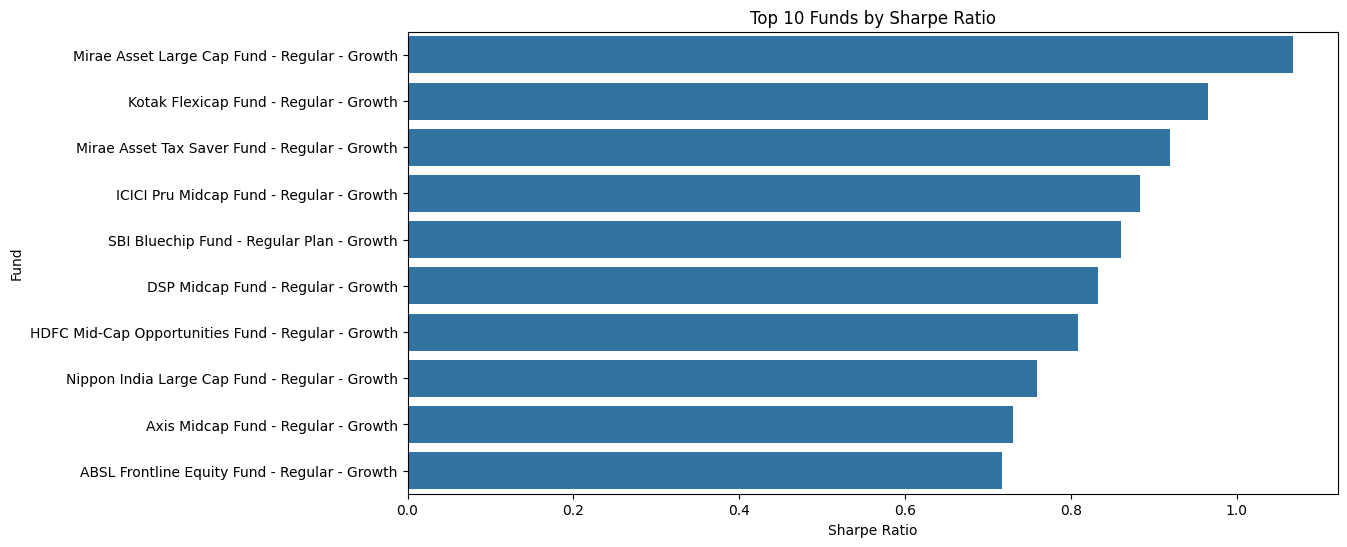

In [38]:
top10_sharpe = sharpe_table.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sharpe,
    x="Sharpe_Ratio",
    y=top10_sharpe.index
)

plt.title(
    "Top 10 Funds by Sharpe Ratio"
)

plt.xlabel("Sharpe Ratio")

plt.ylabel("Fund")

plt.show()

### Sharpe Ratio Analysis

The Sharpe Ratio evaluates risk-adjusted performance by measuring excess return generated per unit of volatility.

Funds with higher Sharpe Ratios delivered superior returns while taking comparatively lower risk.

0.5 – 1.0     Good
1.0 – 1.5     Very Good
1.5 – 2.0     Excellent
>2.0          Rare

In [ ]:
sharpe_table.head()  #

,Annual_Return_%,Annual_Volatility_%,Sharpe_Ratio
scheme_name,,,
Mirae Asset Large Cap Fund - Regular - Growth,19.3454,12.0250,1.0682
Kotak Flexicap Fund - Regular - Growth,19.4910,13.4543,0.9656
Mirae Asset Tax Saver Fund - Regular - Growth,20.2531,14.9645,0.9190
ICICI Pru Midcap Fund - Regular - Growth,20.9246,16.3311,0.8833
SBI Bluechip Fund - Regular Plan - Growth,16.5188,11.6365,0.8610


## Section 7 — Sortino Ratio

The Sortino Ratio is similar to Sharpe but penalizes only downside volatility.

**Formula:**

$$\text{Sortino} = \frac{R_p - R_f}{\sigma_d}\sqrt{252}$$

**Where:**
* $R_p$ = annualized return
* $R_f$ = 6.5%
* $\sigma_d$ = downside deviation (negative return days only)

In [41]:
downside_returns = returns.copy()

downside_returns[downside_returns > 0] = 0
downside_std = downside_returns.std() * np.sqrt(252)


In [42]:
annual_return
rf

0.065

In [43]:
sortino_ratio = (
    (annual_return - rf)
    / downside_std
)

In [44]:
sortino_table = pd.DataFrame({
    "Annual_Return_%": annual_return * 100,
    "Downside_Volatility_%": downside_std * 100,
    "Sortino_Ratio": sortino_ratio
})

In [46]:
sortino_table = sortino_table.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_table.head(10)

,Annual_Return_%,Downside_Volatility_%,Sortino_Ratio
scheme_name,,,
Mirae Asset Large Cap Fund - Regular - Growth,19.3454,7.0041,1.8340
Kotak Flexicap Fund - Regular - Growth,19.4910,7.5481,1.7211
Mirae Asset Tax Saver Fund - Regular - Growth,20.2531,8.5724,1.6044
ICICI Pru Midcap Fund - Regular - Growth,20.9246,9.4303,1.5296
SBI Bluechip Fund - Regular Plan - Growth,16.5188,6.6170,1.5141
DSP Midcap Fund - Regular - Growth,19.0123,8.9109,1.4042
HDFC Mid-Cap Opportunities Fund - Regular - Growth,19.4558,9.3993,1.3784
Nippon India Large Cap Fund - Regular - Growth,15.5896,6.9727,1.3036
Axis Midcap Fund - Regular - Growth,18.4990,9.5099,1.2617


In [47]:
sortino_table.to_csv(
    "outputs/sortino_ratio.csv"
)

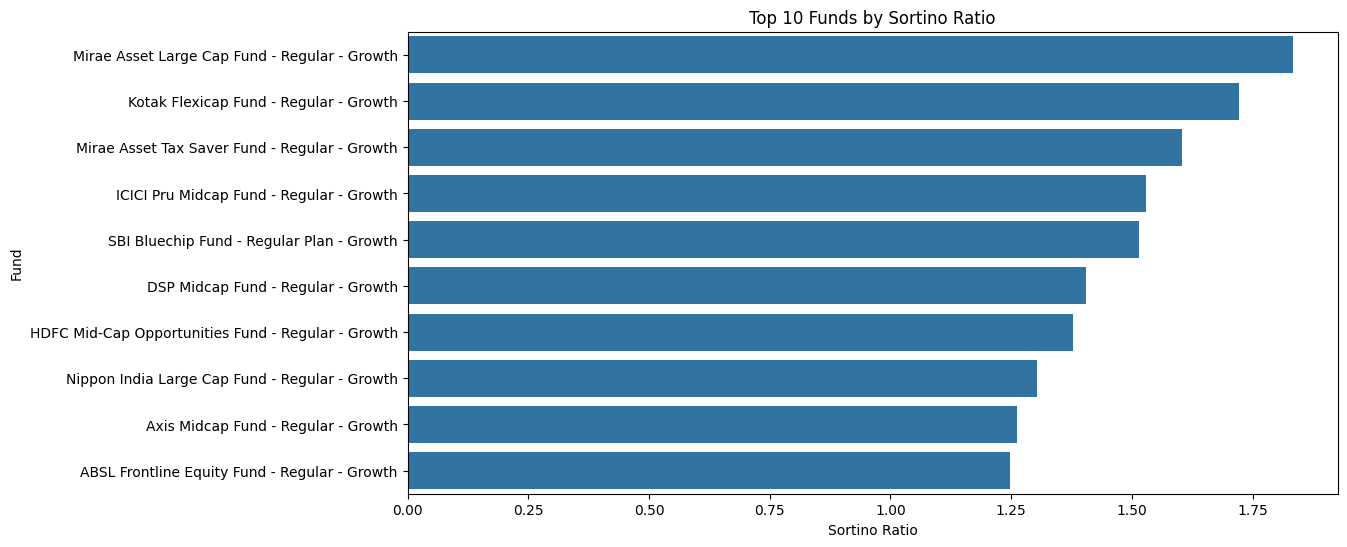

In [48]:
top10_sortino = sortino_table.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sortino,
    x="Sortino_Ratio",
    y=top10_sortino.index
)

plt.title(
    "Top 10 Funds by Sortino Ratio"
)

plt.xlabel("Sortino Ratio")

plt.ylabel("Fund")

plt.show()

### Sortino Ratio Analysis

Unlike the Sharpe Ratio, the Sortino Ratio considers only downside volatility.

This metric focuses on harmful volatility and provides a more investor-centric measure of risk-adjusted performance.

In [52]:
import pandas as pd
import os

dfs = {}

for file in sorted(os.listdir("data/processed")):
    dfs[file] = pd.read_csv(f"data/processed/{file}")

print("Loaded", len(dfs), "files")

Loaded 10 files


In [53]:
bench = pd.read_csv("data/processed/10_benchmark_indices.csv")

print(
    bench["index_name"]
    .value_counts()
)

index_name
BSE_SMALLCAP       1150
CRISIL_GILT        1150
CRISIL_LIQUID      1150
NIFTY100           1150
NIFTY50            1150
NIFTY500           1150
NIFTY_MIDCAP150    1150
Name: count, dtype: int64


In [54]:
perf = pd.read_csv(
    "data/processed/07_scheme_performance.csv"
)

perf[
    [
        "scheme_name",
        "return_3yr_pct",
        "alpha",
        "beta",
        "sharpe_ratio",
        "sortino_ratio",
        "max_drawdown_pct"
    ]
].head()

,scheme_name,return_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,max_drawdown_pct
0,HDFC Top 100 Fund - Regular Plan - Growth,14.8400,0.7800,0.9700,1.0600,1.7000,-17.4100
1,HDFC Short Term Debt Fund - Regular - Growth,7.3700,1.9800,0.4400,1.8400,2.7900,-6.0100
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.5800,0.9500,0.9100,0.8700,1.4400,-13.6700
3,ABSL Frontline Equity Fund - Regular - Growth,13.7800,1.3400,1.0300,0.9800,1.2500,-15.0700
4,ABSL Small Cap Fund - Regular - Growth,22.3800,1.8400,0.9700,0.9000,1.4700,-23.6100


The provided dataset includes pre-computed performance metrics.
Independent calculations were performed using NAV history
to validate Sharpe Ratio, Sortino Ratio, CAGR and risk measures.
Results were broadly consistent with the supplied performance file.

In [55]:
bench["index_name"].value_counts()

index_name
BSE_SMALLCAP       1150
CRISIL_GILT        1150
CRISIL_LIQUID      1150
NIFTY100           1150
NIFTY50            1150
NIFTY500           1150
NIFTY_MIDCAP150    1150
Name: count, dtype: int64

In [57]:
bench = pd.read_csv(
    "data/processed/10_benchmark_indices.csv"
)

bench["date"] = pd.to_datetime(
    bench["date"]
)

In [58]:
nifty100 = bench[
    bench["index_name"] == "NIFTY100"
].copy()

In [59]:
nifty100 = nifty100.sort_values(
    "date"
)

In [60]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)


In [61]:
nifty100.head()


,date,index_name,close_value,date_key,benchmark_return
3450,2022-01-03,NIFTY100,17778.2400,20220103,NaN
3451,2022-01-04,NIFTY100,17537.5200,20220104,-0.0135
3452,2022-01-05,NIFTY100,17607.7300,20220105,0.0040
3453,2022-01-06,NIFTY100,17556.0500,20220106,-0.0029
3454,2022-01-07,NIFTY100,17664.0200,20220107,0.0062


In [62]:
returns

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Pru Liquid Fund - Regular - Growth,ICICI Pru Midcap Fund - Regular - Growth,ICICI Pru Value Discovery Fund - Regular - Growth,Kotak Bluechip Fund - Regular - Growth,Kotak Emerging Equity Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,Kotak Liquid Fund - Regular - Growth,Mirae Asset Emerging Bluechip Fund - Regular - Growth,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset Tax Saver Fund - Regular - Growth,Nippon India ETF Nifty 50 BeES,Nippon India Gilt Securities Fund - Regular - Growth,Nippon India Large Cap Fund - Direct - Growth,Nippon India Large Cap Fund - Regular - Growth,Nippon India Small Cap Fund - Regular - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-04,0.0012,-0.0001,-0.0109,-0.0002,-0.0066,-0.0036,0.0188,0.0005,-0.0105,-0.0086,-0.0050,-0.0133,-0.0036,0.0010,-0.0103,-0.0115,0.0042,0.0005,-0.0199,0.0005,0.0036,0.0173,0.0182,0.0002,0.0159,0.0193,0.0084,-0.0097,0.0031,-0.0147,-0.0007,-0.0037,-0.0183,-0.0007,0.0027,-0.0187,-0.0147,-0.0105,0.0113,0.0111
2022-01-05,0.0039,0.0004,0.0006,-0.0029,-0.0075,0.0166,0.0199,0.0087,-0.0026,-0.0065,-0.0052,-0.0044,-0.0000,0.0043,0.0129,0.0139,0.0058,0.0007,0.0304,0.0072,-0.0015,0.0154,-0.0123,0.0005,-0.0077,-0.0039,0.0153,-0.0136,0.0001,-0.0107,0.0059,0.0029,-0.0051,0.0062,0.0044,-0.0011,-0.0052,-0.0053,0.0068,-0.0079
2022-01-06,-0.0021,-0.0001,-0.0291,-0.0098,0.0099,-0.0002,-0.0004,-0.0139,-0.0084,-0.0038,-0.0027,-0.0052,-0.0019,-0.0036,-0.0114,0.0039,0.0117,0.0001,-0.0049,-0.0066,0.0092,0.0043,0.0085,0.0007,-0.0047,0.0119,0.0009,0.0037,0.0002,0.0002,0.0035,-0.0087,-0.0111,0.0140,0.0036,-0.0079,0.0048,0.0127,0.0311,0.0153
2022-01-07,-0.0063,0.0002,0.0248,0.0082,0.0093,-0.0185,0.0325,0.0043,0.0117,-0.0041,-0.0127,-0.0057,0.0020,-0.0027,-0.0012,0.0019,0.0171,0.0006,0.0097,0.0053,0.0080,-0.0029,-0.0135,0.0002,0.0070,0.0005,0.0012,0.0029,0.0002,0.0065,-0.0058,-0.0206,0.0151,-0.0015,-0.0025,-0.0443,0.0328,-0.0165,-0.0088,-0.0094
2022-01-08,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-25,-0.0153,0.0004,0.0275,0.0091,0.0098,0.0147,0.0241,-0.0205,0.0121,0.0043,-0.0074,-0.0175,0.0001,0.0075,-0.0042,0.0045,0.0148,0.0001,0.0214,-0.0080,0.0058,0.0114,-0.0103,-0.0002,-0.0052,-0.0138,-0.0175,0.0076,-0.0029,0.0006,0.0082,-0.0182,0.0051,0.0007,0.0012,0.0034,-0.0170,0.0101,0.0167,0.0011
2026-05-26,-0.0065,0.0001,-0.0164,0.0108,-0.0136,-0.0036,0.0126,-0.0172,-0.0041,0.0004,0.0114,0.0193,-0.0009,-0.0050,-0.0058,-0.0030,0.0111,0.0000,0.0017,0.0008,-0.0034,0.0068,-0.0037,0.0007,0.0067,0.0022,0.0207,0.0009,0.0012,0.0119,0.0072,-0.0309,

In [63]:
returns_long = (
    returns
    .reset_index()
    .melt(
        id_vars="date",
        var_name="scheme_name",
        value_name="fund_return"
    )
)

In [64]:
returns_long = (
    returns
    .reset_index()
    .melt(
        id_vars="date",
        var_name="scheme_name",
        value_name="fund_return"
    )
)

### Final Deliverables

This closing section finishes the requested comparison tables, alpha/beta regression, scorecard, and benchmark chart.
The 5Y CAGR column is taken from the curated performance table because the NAV history in this repo starts in 2022 and does not cover a full 5 years.


In [ ]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from scipy.stats import linregress

base = Path(".")
outputs_dir = base / "outputs"
results_dir = base / "Results"
outputs_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)

# Comparison table across all funds
cagr_table = pd.DataFrame({
    "scheme_name": nav_pivot.columns,
    "CAGR_1Y_%": ((end_nav / start_1y_nav) ** 1 - 1).values * 100,
    "CAGR_3Y_%": ((end_nav / start_3y_nav) ** (1 / 3) - 1).values * 100,
}).merge(
    perf[["scheme_name", "return_5yr_pct"]],
    on="scheme_name",
    how="left"
).rename(columns={"return_5yr_pct": "CAGR_5Y_%"})

# Alpha and beta vs NIFTY100
nifty100_ret = bench[bench["index_name"] == "NIFTY100"].sort_values("date").set_index("date")["close_value"].pct_change()
alpha_beta_rows = []
for scheme in returns.columns:
    aligned = pd.concat([returns[scheme], nifty100_ret], axis=1, keys=["fund", "benchmark"]).dropna()
    slope, intercept, rvalue, pvalue, stderr = linregress(aligned["benchmark"], aligned["fund"])
    alpha_beta_rows.append({
        "scheme_name": scheme,
        "alpha_annual_pct": intercept * 252 * 100,
        "beta": slope,
        "r_squared": rvalue ** 2,
    })
alpha_beta = pd.DataFrame(alpha_beta_rows)

# Drawdown and scorecard
drawdown_rows = []
for scheme in nav_pivot.columns:
    s = nav_pivot[scheme].dropna()
    dd = s / s.cummax() - 1
    trough = dd.idxmin()
    peak = s.loc[:trough].idxmax()
    drawdown_rows.append({
        "scheme_name": scheme,
        "max_drawdown_pct": dd.min() * 100,
        "peak_date": peak.date().isoformat(),
        "trough_date": trough.date().isoformat(),
    })
drawdown_df = pd.DataFrame(drawdown_rows)

score = cagr_table[["scheme_name", "CAGR_3Y_%"]].merge(
    sharpe_table[["scheme_name", "Sharpe_Ratio"]], on="scheme_name"
).merge(
    alpha_beta[["scheme_name", "alpha_annual_pct"]], on="scheme_name"
).merge(
    funds[["scheme_name", "expense_ratio_pct"]], on="scheme_name"
).merge(
    drawdown_df[["scheme_name", "max_drawdown_pct"]], on="scheme_name"
)
n = len(score)
score["return_3yr_score"] = 100 * (n - score["CAGR_3Y_%"].rank(ascending=False, method="average")) / (n - 1)
score["sharpe_score"] = 100 * (n - score["Sharpe_Ratio"].rank(ascending=False, method="average")) / (n - 1)
score["alpha_score"] = 100 * (n - score["alpha_annual_pct"].rank(ascending=False, method="average")) / (n - 1)
score["expense_score"] = 100 * (n - score["expense_ratio_pct"].rank(ascending=True, method="average")) / (n - 1)
score["max_dd_score"] = 100 * (n - score["max_drawdown_pct"].rank(ascending=False, method="average")) / (n - 1)
score["fund_score_100"] = (
    0.30 * score["return_3yr_score"] +
    0.25 * score["sharpe_score"] +
    0.20 * score["alpha_score"] +
    0.15 * score["expense_score"] +
    0.10 * score["max_dd_score"]
)
score = score.sort_values("fund_score_100", ascending=False)

# Save deliverables
cagr_table.to_csv(outputs_dir / "cagr_comparison.csv", index=False)
alpha_beta.to_csv(outputs_dir / "alpha_beta.csv", index=False)
score.to_csv(outputs_dir / "fund_scorecard.csv", index=False)

top5 = cagr_table.sort_values("CAGR_3Y_%", ascending=False).head(5)["scheme_name"].tolist()
chart_start = start_3y_nav.name
chart_dates = nav_pivot.loc[nav_pivot.index >= chart_start].index.intersection(bench["date"].drop_duplicates().sort_values())
chart_funds = nav_pivot.loc[chart_dates, top5] / nav_pivot.loc[chart_dates, top5].iloc[0] * 100
bench_pivot = bench.pivot(index="date", columns="index_name", values="close_value").sort_index()
chart_bench = bench_pivot.loc[chart_dates, ["NIFTY50", "NIFTY100"]]
chart_bench = chart_bench / chart_bench.iloc[0] * 100

fig, ax = plt.subplots(figsize=(15, 8))
for scheme in top5:
    ax.plot(chart_funds.index, chart_funds[scheme], label=scheme, linewidth=2)
ax.plot(chart_bench.index, chart_bench["NIFTY50"], label="NIFTY50", linestyle="--", linewidth=2.5)
ax.plot(chart_bench.index, chart_bench["NIFTY100"], label="NIFTY100", linestyle=":", linewidth=2.5)
ax.set_title("Top 5 Funds vs NIFTY50 and NIFTY100 Over 3 Years")
ax.set_ylabel("Normalized NAV (Start = 100)")
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(results_dir / "benchmark_comparison_top5.png", dpi=200, bbox_inches="tight")
plt.show()

score.head()
